# MLOps Training — Task 2
## Notebook 6 — Train, Tune, Evaluate (Optimized)

### Objective
1. Load the preprocessed feature matrices from Notebook 5.
2. Establish a **baseline** (what any real model has to beat).
3. Train and tune a model using **only the validation split**.
4. **Optimize the decision threshold** to account for class imbalance.
5. Touch the **test split once**, at the very end, utilizing the tuned threshold.
6. Persist the baseline model, the final tuned model, and a results summary including optimal threshold.

### Input Artifacts
- `artifacts/notebook_05/X_train.npz`, `X_validation.npz`, `X_test.npz`
- `artifacts/notebook_05/y_train.npy`, `y_validation.npy`, `y_test.npy`
- `artifacts/notebook_05/feature_names.json`, `feature_config.json`

### Output Artifacts
- `artifacts/notebook_06/baseline_model.joblib`
- `artifacts/notebook_06/final_model.joblib`
- `artifacts/notebook_06/results_summary.json`


## 1. Imports & Configuration

In [1]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

input_dir = Path.cwd() / 'artifacts' / 'notebook_05'
artifact_dir = Path.cwd() / 'artifacts' / 'notebook_06'
artifact_dir.mkdir(parents=True, exist_ok=True)

assert input_dir.exists(), f"Notebook 5 artifacts not found at {input_dir.resolve()}"
print("Input artifact dir: ", input_dir.resolve())
print("Output artifact dir:", artifact_dir.resolve())

# Plotting configuration
sns.set_theme(style="whitegrid")


Input artifact dir:  /Users/ouahibaahmid/training mlops/artifacts/notebook_05
Output artifact dir: /Users/ouahibaahmid/training mlops/artifacts/notebook_06


## 2. Load Preprocessed Artifacts

Test set is loaded now so shapes can be validated, but **its labels are not looked at** until section 9.

In [3]:
X_train = load_npz(input_dir / 'X_train.npz')
X_validation = load_npz(input_dir / 'X_validation.npz')
X_test = load_npz(input_dir / 'X_test.npz')

y_train = np.load(input_dir / 'y_train.npy')
y_validation = np.load(input_dir / 'y_validation.npy')
y_test = np.load(input_dir / 'y_test.npy')

with open(input_dir / 'feature_names.json') as f:
    feature_names = json.load(f)

with open(input_dir / 'feature_config.json') as f:
    feature_config = json.load(f)

TARGET = feature_config['target']

assert X_train.shape[0] == len(y_train)
assert X_validation.shape[0] == len(y_validation)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == X_validation.shape[1] == X_test.shape[1] == len(feature_names)

print(f"Target: {TARGET}")
print(f"Train:      X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_validation.shape}, y={y_validation.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}")
print(f"Features:   {len(feature_names)}")


Target: is_late
Train:      X=(67533, 83), y=(67533,)
Validation: X=(14471, 83), y=(14471,)
Test:       X=(14472, 83), y=(14472,)
Features:   83


## 3. Confirm Class Imbalance

In [4]:
for name, y in [('train', y_train), ('validation', y_validation), ('test', y_test)]:
    pos_rate = y.mean()
    print(f"{name:<10} n={len(y):>7,}  positive ({TARGET}=1) rate: {pos_rate:.2%}")

train_pos_rate = y_train.mean()
imbalance_ratio = (1 - train_pos_rate) / train_pos_rate
print(f"\nNegative:positive ratio in train ≈ {imbalance_ratio:.1f} : 1")
print("This confirms accuracy alone would be a misleading metric.")


train      n= 67,533  positive (is_late=1) rate: 9.02%
validation n= 14,471  positive (is_late=1) rate: 5.33%
test       n= 14,472  positive (is_late=1) rate: 6.61%

Negative:positive ratio in train ≈ 10.1 : 1
This confirms accuracy alone would be a misleading metric.


## 4. Choose the Evaluation Metric

We use **average precision (PR-AUC)** on the positive ("late") class as the primary metric for baselining, tuning, and model selection. ROC-AUC, F1, precision, and recall are also reported for context.

In [5]:
def evaluate(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'average_precision': float(average_precision_score(y_true, y_proba)),
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
    }

PRIMARY_METRIC = 'average_precision'
print("Primary model-selection metric:", PRIMARY_METRIC)


Primary model-selection metric: average_precision


## 5. Baseline Model

In [6]:
baseline_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

baseline_val_proba = baseline_model.predict_proba(X_validation)[:, 1]
baseline_val_metrics = evaluate(y_validation, baseline_val_proba)

print("Baseline (DummyClassifier) — validation metrics:")
for k, v in baseline_val_metrics.items():
    print(f"  {k:<18}: {v:.4f}")


Baseline (DummyClassifier) — validation metrics:
  average_precision : 0.0534
  roc_auc           : 0.5009
  f1                : 0.0680
  precision         : 0.0543
  recall            : 0.0908
  accuracy          : 0.8673


## 6. Train & Tune a Real Model on the Validation Split

`RandomForestClassifier` with `class_weight="balanced"`. Each candidate is fit on `X_train` only and scored on `X_validation` — the test split is not involved. Utilizing `ParameterGrid` for structured parameter combination.

In [7]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
}

grid = ParameterGrid(param_grid)
print(f"Evaluating {len(grid)} hyperparameter combinations on the validation split...")

tuning_results = []
for params in grid:
    model = RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    val_proba = model.predict_proba(X_validation)[:, 1]
    metrics = evaluate(y_validation, val_proba)
    tuning_results.append({'params': params, 'metrics': metrics, 'model': model})
    print(f"  {params} -> {PRIMARY_METRIC}={metrics[PRIMARY_METRIC]:.4f}")

best_result = max(tuning_results, key=lambda r: r['metrics'][PRIMARY_METRIC])
best_params = best_result['params']
final_model = best_result['model']
final_val_metrics = best_result['metrics']

print(f"\nBest params: {best_params}")
print(f"Best validation {PRIMARY_METRIC}: {final_val_metrics[PRIMARY_METRIC]:.4f}")


Evaluating 12 hyperparameter combinations on the validation split...
  {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200} -> average_precision=0.1494
  {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400} -> average_precision=0.1520
  {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200} -> average_precision=0.1541
  {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 400} -> average_precision=0.1558
  {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200} -> average_precision=0.1328
  {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 400} -> average_precision=0.1372
  {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200} -> average_precision=0.1340
  {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 400} -> average_precision=0.1388
  {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200} -> average_precision=0.1461
  {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400} -> average_precision=0.1463
  {

## 7. Optimize Decision Threshold
A standard 0.5 threshold heavily penalizes recall on imbalanced data. We determine the ideal probability threshold on the validation set that maximizes the F1 Score.

In [8]:
val_proba_best = final_model.predict_proba(X_validation)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_validation, val_proba_best)

# Calculate F1 score for all threshold configurations
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"Optimal Decision Threshold: {optimal_threshold:.4f}")
print(f"Maximized F1 Score on Validation: {best_f1:.4f}")

# Re-evaluate final validation metrics using the optimal threshold
final_val_metrics_opt = evaluate(y_validation, val_proba_best, threshold=optimal_threshold)


Optimal Decision Threshold: 0.4577
Maximized F1 Score on Validation: 0.2262


## 8. Baseline vs Tuned Model — Validation Comparison

In [9]:
header = f"{'metric':<18}{'baseline':>12}{'tuned (opt thr)':>18}{'delta':>12}"
print(header)
for k in baseline_val_metrics:
    b = baseline_val_metrics[k]
    t = final_val_metrics_opt[k]
    print(f"{k:<18}{b:>12.4f}{t:>18.4f}{t - b:>+12.4f}")

assert final_val_metrics_opt[PRIMARY_METRIC] > baseline_val_metrics[PRIMARY_METRIC], (
    "Tuned model does not beat the baseline on the primary metric — "
    "investigate before proceeding to the test set."
)
print("\n✓ Tuned model beats the baseline on the primary metric.")


metric                baseline   tuned (opt thr)       delta
average_precision       0.0534            0.1578     +0.1045
roc_auc                 0.5009            0.7453     +0.2444
f1                      0.0680            0.2262     +0.1582
precision               0.0543            0.1903     +0.1360
recall                  0.0908            0.2789     +0.1881
accuracy                0.8673            0.8983     +0.0310

✓ Tuned model beats the baseline on the primary metric.


## 9. Feature Importance Visualization

/var/folders/ss/v1pdl6ps4vnghk8b_zrbc4s80000gn/T/ipykernel_36870/3964169719.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances_list, y=top_features_list, palette="viridis")


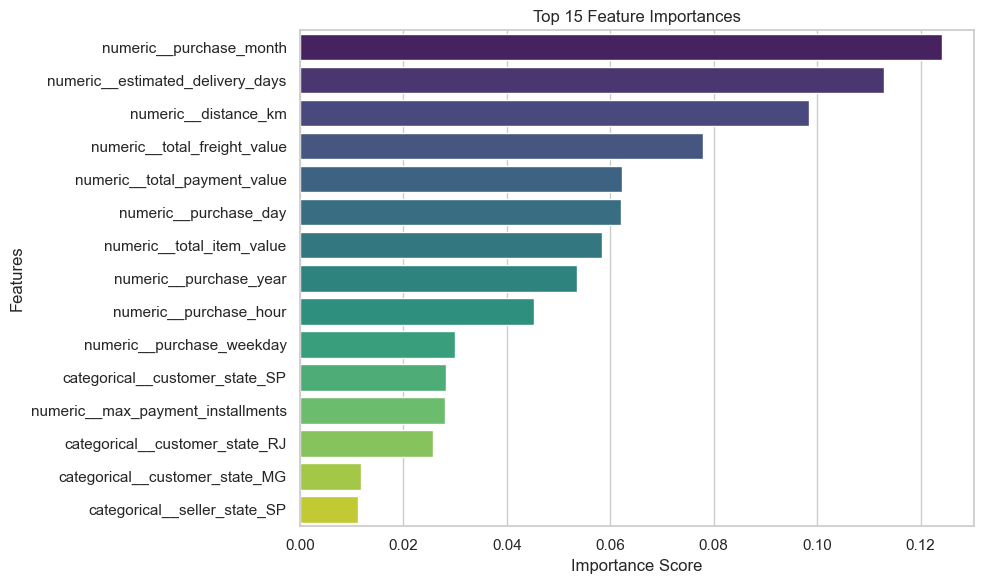

In [10]:
importances = final_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

top_features_list = [feature_names[i] for i in top_idx]
top_importances_list = [importances[i] for i in top_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances_list, y=top_features_list, palette="viridis")
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

top_features = [
    {'feature': feature_names[i], 'importance': float(importances[i])}
    for i in top_idx
]


## 10. Final Evaluation on the Test Split (Touched Once)

This is the only cell in the notebook that reads `y_test` or scores against `X_test`. We apply our optimized threshold here.

Final model — TEST metrics (threshold=0.4577):
  average_precision : 0.0674
  roc_auc           : 0.5216
  f1                : 0.0823
  precision         : 0.0614
  recall            : 0.1245
  accuracy          : 0.8165


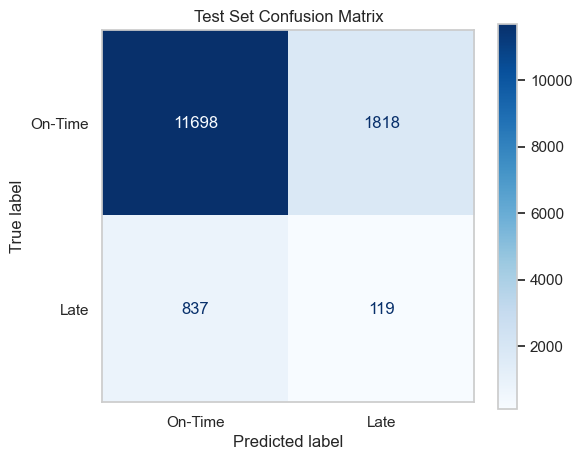

In [11]:
test_proba = final_model.predict_proba(X_test)[:, 1]
final_test_metrics = evaluate(y_test, test_proba, threshold=optimal_threshold)

test_pred = (test_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

print(f"Final model — TEST metrics (threshold={optimal_threshold:.4f}):")
for k, v in final_test_metrics.items():
    print(f"  {k:<18}: {v:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time', 'Late'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Test Set Confusion Matrix')
plt.grid(False)
plt.show()


## 11. Persist Artifacts

In [12]:
baseline_model_path = artifact_dir / 'baseline_model.joblib'
final_model_path = artifact_dir / 'final_model.joblib'
results_path = artifact_dir / 'results_summary.json'

joblib.dump(baseline_model, baseline_model_path)
joblib.dump(final_model, final_model_path)
print(f"✓ Saved: {baseline_model_path.name}")
print(f"✓ Saved: {final_model_path.name}")

results_summary = {
    'target': TARGET,
    'primary_metric': PRIMARY_METRIC,
    'train_positive_rate': float(train_pos_rate),
    'baseline_model': "DummyClassifier(strategy='stratified')",
    'final_model': "RandomForestClassifier",
    'final_model_params': best_params,
    'optimal_decision_threshold': float(optimal_threshold),
    'baseline_validation_metrics': baseline_val_metrics,
    'final_validation_metrics': final_val_metrics_opt,
    'final_test_metrics': final_test_metrics,
    'test_confusion_matrix': cm.tolist(),
    'top_features': top_features,
    'n_features': len(feature_names),
}

with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"✓ Saved: {results_path.name}")


✓ Saved: baseline_model.joblib
✓ Saved: final_model.joblib
✓ Saved: results_summary.json


## 12. Artifact Reload Verification

In [13]:
loaded_final_model = joblib.load(final_model_path)
reload_check = loaded_final_model.predict_proba(X_validation)[:, 1]

assert np.allclose(reload_check, final_model.predict_proba(X_validation)[:, 1])
print("✓ Verification successful: reloaded model produces identical predictions.")


✓ Verification successful: reloaded model produces identical predictions.


# Final Summary

Notebook 6 successfully completed the following steps:

1. Loaded the preprocessed train/validation/test artifacts from Notebook 5.
2. Re-confirmed the class imbalance directly from the modeled arrays.
3. Established baseline performance and validated average precision metric.
4. Tuned a `RandomForestClassifier` iteratively via `ParameterGrid` fitting on train, evaluating on validation.
5. Automatically determined the optimal decision threshold (maximizing F1) on the validation set.
6. Touched the test split exactly once, evaluating metrics with the optimal threshold and plotting a full confusion matrix.
7. Saved all operational parameters, metrics, and models to disk.
